In [2]:
#importação de bibliotecas
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [4]:
#Carregando arquivo

pasta = Path(r'C:\Users\rehfe\Desktop\Curso\Analise com python\Case VAREJO\Base csv')
arquivo = pasta / 'Base Varejo.csv'

df_var = pd.read_csv(arquivo, sep=';')
df_var = df_var.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'])

print('dados carregados')


dados carregados


In [5]:
# Informações básicas do dataset
print(f" O dataset tem {df_var.shape[0]} linhas e {df_var.shape[1]} colunas")
print()
print("📋 Tipo de dado de cada coluna:")
print(df_var.dtypes)
print(df_var.describe())

 O dataset tem 830000 linhas e 10 colunas

📋 Tipo de dado de cada coluna:
DATA           str
CO_ID        int64
CL_ID        int64
CL_GENERO      str
CL_EC        int64
CL_FHL       int64
CL_SEG         str
PR_ID        int64
PR_CAT         str
PR_NOME        str
dtype: object
              CO_ID          CL_ID          CL_EC        CL_FHL          PR_ID
count  830000.00000  830000.000000  830000.000000  830000.00000  830000.000000
mean   460045.08989     499.595204       2.596911       1.14654     115.051855
std    265465.24754     287.568253       1.170599       1.41696      66.129241
min      1000.00000       1.000000       1.000000       0.00000       1.000000
25%    233117.00000     254.000000       2.000000       0.00000      58.000000
50%    456517.00000     498.000000       3.000000       0.00000     115.000000
75%    690132.00000     746.000000       4.000000       2.00000     172.000000
max    919822.00000    1000.000000       5.000000       4.00000     229.000000


In [6]:
#Tratar nulos
print(df_var.isnull().sum())
print()
df_var = df_var.replace({'NULL': np.nan, 'N/A': np.nan, '': np.nan,'#N/D': 'OUTROS'})
print(df_var.isnull().sum())
print()

# Verificar string vazia
df_vazia = df_var['PR_NOME'].str.strip() == ''
print("Após str.strip() == '': ", df_vazia.sum(), "vazios")


DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

Após str.strip() == '':  0 vazios


In [7]:
#Tratar colunas duplicadas
print(f"Linhas completamente iguais: {df_var.duplicated().sum()}")
print()
df_var2 = df_var.drop_duplicates()
print(f"Linhas completamente iguais: {df_var2.duplicated().sum()}")
print()
print(f" O dataset tem {df_var2.shape[0]} linhas e {df_var2.shape[1]} colunas")

Linhas completamente iguais: 96553

Linhas completamente iguais: 0

 O dataset tem 733447 linhas e 10 colunas


In [8]:
#Fomartar a coluna data para datetime
print(df_var2.dtypes)
print()
df_var2['DATA_MOD'] = pd.to_datetime(df_var2['DATA'], format='%d/%m/%Y', errors='coerce')
print(df_var2.dtypes)

DATA           str
CO_ID        int64
CL_ID        int64
CL_GENERO      str
CL_EC        int64
CL_FHL       int64
CL_SEG         str
PR_ID        int64
PR_CAT         str
PR_NOME        str
dtype: object

DATA                    str
CO_ID                 int64
CL_ID                 int64
CL_GENERO               str
CL_EC                 int64
CL_FHL                int64
CL_SEG                  str
PR_ID                 int64
PR_CAT                  str
PR_NOME                 str
DATA_MOD     datetime64[us]
dtype: object


In [9]:
# Filtra as linhas onde a data é inválida isna()
linhas_invalidas = df_var2[df_var2['DATA_MOD'].isna()]
print(linhas_invalidas)

Empty DataFrame
Columns: [DATA, CO_ID, CL_ID, CL_GENERO, CL_EC, CL_FHL, CL_SEG, PR_ID, PR_CAT, PR_NOME, DATA_MOD]
Index: []


In [9]:
#Estatísticas descritivas da coluna filhos
print(df_var2['CL_FHL'].describe().map('{:,.2f}'.format))

count    733,447.00
mean           1.15
std            1.42
min            0.00
25%            0.00
50%            0.00
75%            2.00
max            4.00
Name: CL_FHL, dtype: str


In [10]:
#Configura para o padrão do Brasil
import locale
locale.setlocale(locale.LC_ALL, 'pt_BR.utf8')

'pt_BR.utf8'

In [11]:
#Analise de vendas por genero
QTD_GEN = pd.pivot_table(
    df_var2,
    values="PR_ID",
    index="CL_GENERO",  
    aggfunc="sum",       
    fill_value=0         
)

QTD_GEN = QTD_GEN / 1000000
print(QTD_GEN.map('R$ {:,.2f}M'.format))
print()


               PR_ID
CL_GENERO           
F          R$ 44.00M
M          R$ 40.37M



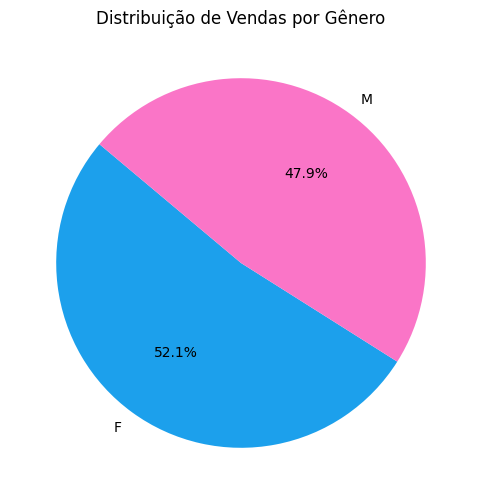

In [12]:
#Gráfico de pizza para a distribuição de vendas por gênero
cores = ["#1CA0EC","#FA75C7"]

QTD_GEN.plot.pie(
    y="PR_ID", 
    autopct='%.1f%%', 
    figsize=(8, 6),
    colors=cores,        
    startangle=140,
    legend=False 
)

plt.title('Distribuição de Vendas por Gênero')
plt.ylabel('')             
plt.show()

In [13]:
#Analise de vendas por categoria
QTD_CAT = pd.pivot_table(
    df_var2,
    values="PR_ID",
    index="PR_CAT",  
    aggfunc="sum",     
    fill_value=0
)

QTD_CAT = QTD_CAT / 1000000

print(QTD_CAT.map('R$ {:,.2f}M'.format))


                PR_ID
PR_CAT               
ACESSORIOS   R$ 1.20M
ALIMENTOS   R$ 40.45M
BEBIDAS      R$ 4.19M
HIGIENE     R$ 17.14M
LIMPEZA     R$ 17.32M
OUTROS       R$ 0.35M
PET          R$ 3.72M


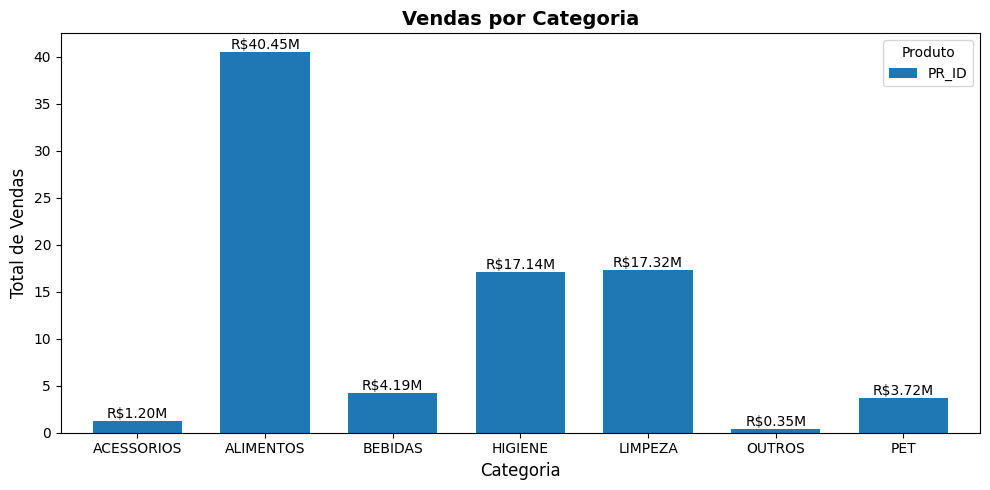

In [14]:
#Gráfico de barras para a distribuição de vendas por categoria

fig, ax = plt.subplots(figsize=(10, 5))

grafico = QTD_CAT.plot(kind='bar',ax=ax, stacked=True, width=0.7)


ax.set_title('Vendas por Categoria', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria', fontsize=12)
ax.set_ylabel('Total de Vendas', fontsize=12)

ax.bar_label(ax.containers[0], label_type="edge", color='black', fmt='R${:.2f}M')
if len(ax.containers) > 1:
    ax.bar_label(ax.containers[1], label_type="edge", color='black', fmt='R${:.2f}M')

plt.xticks(rotation=0)
plt.legend(title='Produto')
plt.tight_layout()
plt.show()

In [15]:
#acrescenta coluna mês e ano

df_var2['MES'] = df_var2['DATA_MOD'].dt.strftime('%b')
df_var2['ANO'] = df_var2['DATA_MOD'].dt.year
#print(df_var2.head())

In [16]:
#Analise Receita por mês
QTD_VEN = pd.pivot_table(
    df_var2,
    values="PR_ID",
    index="MES",  
    aggfunc="sum",      
    fill_value=0, 
    margins=True,
    margins_name='Total Geral'       
)

QTD_VEN = QTD_VEN.reindex(index=['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez'])
QTD_VEN = QTD_VEN / 1000000
print(QTD_VEN.map('R$ {:,.2f}M'.format))
print()


        PR_ID
MES          
jan  R$ 8.52M
fev  R$ 7.74M
mar  R$ 6.54M
abr  R$ 6.80M
mai  R$ 8.39M
jun  R$ 6.89M
jul  R$ 6.99M
ago  R$ 6.69M
set  R$ 6.97M
out  R$ 7.51M
nov  R$ 4.16M
dez  R$ 7.18M



In [17]:
#Analise Receita ao longo dos anos
QTD_VEN_2 = pd.pivot_table(
    df_var2,
    values="PR_ID",
    index="ANO", 
    aggfunc="sum",      
    fill_value=0      
)

QTD_VEN_2 = QTD_VEN_2 / 1000000
print(QTD_VEN_2.map('R$ {:,.2f}M'.format))
print()


          PR_ID
ANO            
2019  R$ 20.26M
2020  R$ 22.22M
2021  R$ 24.92M
2022  R$ 16.97M



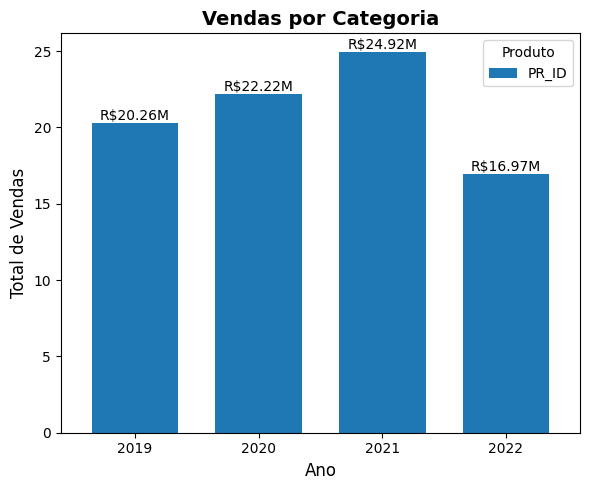

In [18]:
#Gráfico de barras para a distribuição de vendas por ano
fig, ax = plt.subplots(figsize=(6, 5))

grafico = QTD_VEN_2.plot(kind='bar',ax=ax, stacked=True, width=0.7)


ax.set_title('Vendas por Categoria', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Total de Vendas', fontsize=12)

ax.bar_label(ax.containers[0], label_type="edge", color='black', fmt='R${:.2f}M')
if len(ax.containers) > 1:
    ax.bar_label(ax.containers[1], label_type="edge", color='black', fmt='R${:.2f}M')

plt.xticks(rotation=0)
plt.legend(title='Produto')
plt.tight_layout()
plt.show()

In [ ]:
#Analise de vendas por categoria anual
QTD_CAT_2 = pd.pivot_table(
    df_var2,
    values="PR_ID",
    columns="ANO",
    index="PR_CAT",  
    aggfunc="sum",     
    fill_value=0
)

QTD_CAT_2 = QTD_CAT_2 / 1000000

print(QTD_CAT_2.map('R$ {:,.2f}M'.format))

ANO             2019       2020       2021      2022
PR_CAT                                              
ACESSORIOS  R$ 0.29M   R$ 0.32M   R$ 0.35M  R$ 0.25M
ALIMENTOS   R$ 9.69M  R$ 10.65M  R$ 11.98M  R$ 8.13M
BEBIDAS     R$ 1.00M   R$ 1.12M   R$ 1.23M  R$ 0.84M
HIGIENE     R$ 4.13M   R$ 4.51M   R$ 5.07M  R$ 3.44M
LIMPEZA     R$ 4.18M   R$ 4.56M   R$ 5.10M  R$ 3.49M
OUTROS      R$ 0.08M   R$ 0.09M   R$ 0.10M  R$ 0.07M
PET         R$ 0.89M   R$ 0.98M   R$ 1.10M  R$ 0.75M


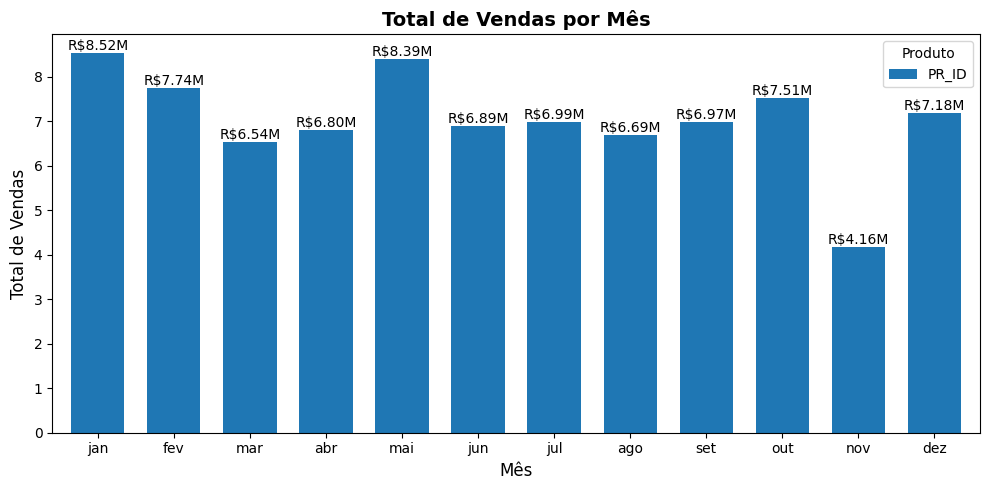

In [ ]:
#Gráfico de barras para a distribuição de vendas por mês
fig, ax = plt.subplots(figsize=(10, 5))

grafico = QTD_VEN.plot(kind='bar',ax=ax, stacked=True, width=0.7)


ax.set_title('Total de Vendas por Mês', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Total de Vendas', fontsize=12)

ax.bar_label(ax.containers[0], label_type="edge", color='black', fmt='R${:.2f}M')
if len(ax.containers) > 1:
    ax.bar_label(ax.containers[1], label_type="edge", color='black', fmt='R${:.2f}M')

plt.xticks(rotation=0)
plt.legend(title='Produto')
plt.tight_layout()
plt.show()

In [ ]:
#Analise  vendas 2022

df_var_2022 = df_var2[df_var2['ANO'] == 2022]


In [ ]:
#Analise de vendas por genero 2022
QTD_GEN22 = pd.pivot_table(
    df_var_2022,
    values="PR_ID",
    index="CL_GENERO",  
    aggfunc="sum",       
    fill_value=0         
)

QTD_GEN22 = QTD_GEN22 / 1000000
print(QTD_GEN.map('R$ {:,.2f}M'.format))
print()

               PR_ID
CL_GENERO           
F          R$ 44.00M
M          R$ 40.37M



In [ ]:
#Analise de vendas por categoria 2022
QTD_VEN22 = pd.pivot_table(
    df_var_2022,
    values="PR_ID",
    index="PR_CAT",
    aggfunc="sum",      
    fill_value=0,       
)

QTD_VEN22 = QTD_VEN22 / 1000000
print(QTD_VEN22.map('R$ {:,.2f}M'.format))
print()

               PR_ID
PR_CAT              
ACESSORIOS  R$ 0.25M
ALIMENTOS   R$ 8.13M
BEBIDAS     R$ 0.84M
HIGIENE     R$ 3.44M
LIMPEZA     R$ 3.49M
OUTROS      R$ 0.07M
PET         R$ 0.75M



In [ ]:
#Analise de vendas mensal 2022

QTD_VEN22 = pd.pivot_table(
    df_var_2022,
    values="PR_ID",
    columns="ANO",
    index="MES",  
    aggfunc="sum",      
    fill_value=0,       
)

QTD_VEN22 = QTD_VEN22.reindex(index=['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez'])
QTD_VEN22 = QTD_VEN22 / 1000000
print(QTD_VEN22.map('R$ {:,.2f}M'.format))
print()

ANO      2022
MES          
jan  R$ 2.64M
fev  R$ 1.91M
mar  R$ 1.61M
abr  R$ 1.43M
mai  R$ 2.01M
jun  R$ 1.39M
jul  R$ 2.02M
ago  R$ 1.29M
set  R$ 0.15M
out  R$ 0.27M
nov  R$ 0.72M
dez  R$ 1.52M

